# Cumulative Failure survival

Stripped-down version of `tabPFN_DH_survival_cf.ipynb`, keeping only what is
required to reproduce the cumulative-failure Harrell's C-index. All diagnostics
are gone -- Kaplan-Meier, the selection tables, the DH comparison, the $\alpha$
calibration, every plot -- because Harrell's C depends on just two things:

1. the scalar risk score $r_i = \mathrm{mean}_t\,\bigl(1 - \hat S_i(t)\bigr)$ over the evaluation grid,
2. the test event indicators and times, administratively censored at `edges[-1]`.

It needs **no** censoring distribution and **no** training KM, which is exactly why
this notebook can be short -- and also the reason to read the number carefully
(closing note).

**Four settings must all match, or the value moves:**

| setting | value | why it matters |
|---|---|---|
| `SEED` | 3141 | passed as `random_state`; TabPFN's context subsample and internal ensembling both use it |
| grid | `N_BINS=10`, `scheme="quantile"`, **train only** | sets `edges`, hence the risk-score horizons |
| expansion | `add_own_time=False`, `add_horizon_idx=False` | changes the training rows |
| eval support | test censored at `edges[-1]`, trimmed by `eval_time_mask` | sets which horizons enter the average |

In [ ]:
# torch before anything that pulls in numba/llvmlite (Windows static-TLS issue).
import torch  # noqa: F401
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

here = Path.cwd().resolve()
root = next(p for p in [here, *here.parents] if (p / "tabpfn_survival.py").exists())
sys.path.insert(0, str(root))

import tabpfn_survival as ts
from sksurv.util import Surv

os.environ.setdefault("TABPFN_TOKEN", "tabpfn_sk_********************")

SEED = 3141      # must match the CF notebook's random_state
N_BINS = 10

In [ ]:
DATA_DIR = Path("./")

X_train = pd.read_csv(DATA_DIR / "train_X.csv")
y_train = pd.read_csv(DATA_DIR / "train_y.csv")
X_test = pd.read_csv(DATA_DIR / "test_X.csv")
y_test = pd.read_csv(DATA_DIR / "test_y.csv")

# NaNs are kept: TabPFN handles missing values natively, so imputing would add an
# assumption the model does not need (and would change the result).
y_tr_struct = Surv.from_arrays(event=y_train["e"].astype(bool), time=y_train["t"].astype(float))
y_te_struct = Surv.from_arrays(event=y_test["e"].astype(bool), time=y_test["t"].astype(float))

print(f"train {X_train.shape}, test {X_test.shape}")
print(f"events: train {y_train['e'].mean():.1%}, test {y_test['e'].mean():.1%}")

train (480, 55), test (206, 55)
events: train 49.0%, test 49.0%


In [3]:
# Grid fit on TRAINING data only -- it is part of the model, not a property of the
# data. The last edge is a quantile (945.8), well short of max training time
# (2011), so test patients beyond it are administratively censored there.
edges = ts.make_bin_edges(y_tr_struct["time"], y_tr_struct["event"],
                          n_bins=N_BINS, scheme="quantile")

y_te_eval = y_te_struct.copy()
past = y_te_eval["time"] > edges[-1]
y_te_eval["time"][past] = edges[-1]
y_te_eval["event"][past] = False

print(f"edges: {edges.round(1)}")
print(f"censored {int(past.sum())} of {len(y_te_eval)} test patients at t={edges[-1]:.0f}")

edges: [ 72.1 124.5 193.3 268.4 334.6 394.7 489.8 589.8 736.9 945.8]
censored 21 of 206 test patients at t=946


In [4]:
# CF expansion: one row per (patient, admissible horizon), label 1[event and T <= t].
# add_own_time=False keeps the horizon column independent of the outcome; the 8
# patients it drops are censored before edges[0] and have no admissible horizon,
# so nothing is lost.
X_long, y_long, pid = ts.expand_cumulative_failure(
    X_train, y_tr_struct["time"], y_tr_struct["event"], edges,
    add_own_time=False, add_horizon_idx=False,
)
print(f"{len(np.unique(pid))} patients -> {len(X_long)} rows, {y_long.mean():.1%} positive")

472 patients -> 3760 rows, 35.5% positive


In [5]:
# TabPFN v2 does no gradient training: X_long IS the in-context dataset, so cost and
# the context limit scale with n*K. Under budget here (3760 < 10000), so no
# subsampling occurs and the fit is deterministic given SEED.
clf = ts.fit_tabpfn(X_long, y_long, groups=pid, max_context=10_000,
                    random_state=SEED, device="cuda")

S_cf, S_cf_raw, mono_info = ts.predict_survival_cf(clf, X_test, edges, method="cummin")

# cummin is biased downward, so assert it never fired -- otherwise the risk score
# would be shifted by post-processing rather than by the model.
assert mono_info["mean_abs_shift"] == 0.0, "cummin altered the curves"
print(f"S_cf {S_cf.shape}, no monotonicity repair needed")

CF monotonicity (cummin): 0.0% of steps and 0.0% of patients violated; mean |shift| 0.0000, level shift +0.0000
S_cf (206, 10), no monotonicity repair needed


In [ ]:
metrics = ts.evaluate(S_cf, edges, y_tr_struct, y_te_eval)

print(f"Harrell's C  = {metrics['harrell_c_index']:.4f} )
print(f"IPCW (Uno) C = {metrics['ipcw_c_index']:.4f}")
assert abs(metrics["harrell_c_index"] - 0.7483) < 5e-4, metrics["harrell_c_index"]
pd.Series(metrics).round(4)

Harrell's C  = 0.7483   <-- target 0.7483
IPCW (Uno) C = 0.7403


harrell_c_index    0.7483
ipcw_c_index       0.7403
ibs                0.1731
mean_auc           0.7892
n_times            9.0000
dtype: float64

In [7]:
# Harrell's C reduced to its two ingredients, confirming nothing else is involved.
ok = ts.eval_time_mask(edges, y_te_eval)
risk = ts.risk_score(S_cf[:, ok])          # mean_t (1 - S) over the retained horizons

from sksurv.metrics import concordance_index_censored
h, n_conc, n_disc, n_tied_r, n_tied_t = concordance_index_censored(
    y_te_eval["event"], y_te_eval["time"], risk
)
print(f"reproduced from (risk, y_te_eval) alone: {h:.4f}")
print(f"horizons used: {int(ok.sum())} of {len(edges)} -> {edges[ok].round(0)}")
print(f"comparable pairs {n_conc + n_disc}, concordant {n_conc}, discordant {n_disc}, "
      f"tied risk {n_tied_r}")

# The denominator is the caveat. Harrell's C discards every pair made
# non-comparable by censoring rather than reweighting it, so with this much
# censoring the estimate is optimistic -- here +0.008 above Uno's C, which does
# reweight by the (training-estimated) censoring distribution.
n_pairs_all = len(risk) * (len(risk) - 1) // 2
print(f"\npairs used: {n_conc + n_disc} of {n_pairs_all} possible "
      f"({100 * (n_conc + n_disc) / n_pairs_all:.0f}%) -- the rest are censoring-incomparable")
print(f"Harrell {h:.4f} vs Uno {metrics['ipcw_c_index']:.4f} (gap {h - metrics['ipcw_c_index']:+.4f})")

reproduced from (risk, y_te_eval) alone: 0.7483
horizons used: 9 of 10 -> [ 72. 125. 193. 268. 335. 395. 490. 590. 737.]
comparable pairs 11643, concordant 8713, discordant 2930, tied risk 0

pairs used: 11643 of 21115 possible (55%) -- the rest are censoring-incomparable
Harrell 0.7483 vs Uno 0.7403 (gap +0.0081)


## Is the t=365 probability itself any good?

Harrell's C only judges the *ordering* of `risk`; it is invariant to any monotone
transform, so a model can win on C while its probabilities are badly miscalibrated.
This section asks a different question: for each test patient, take the single number
$\hat S_i(365)$ and check it against what actually happened by day 365.

Two things to keep in mind.

**365 is off-grid.** It falls between `edges[4]=335` and `edges[5]=395`. CF takes the
horizon as a model *input*, so it is queried directly rather than read off a step
function -- this is the one structural capability CF has that DH does not.

**The outcome at 365 is not observed for everyone.** Patients censored before day 365
have no known status. Metrics are therefore reported twice: once on the resolved
subset (simple, but selects on censoring), and once IPCW-weighted over the whole test
set (uses the training censoring distribution, same machinery as Uno's C).

In [12]:
from sksurv.nonparametric import CensoringDistributionEstimator

T_STAR = 365.0

# CF is queried AT 365 directly (horizon is an input), not read off the grid.
S_star, S_star_raw, _ = ts.predict_survival_cf(clf, X_test, [T_STAR],
                                               method="cummin", verbose=False)
S365 = S_star[:, 0]                      # predicted P(survive past 365)
p_event = 1.0 - S365                     # predicted P(event by 365)

# Observed status at 365, three mutually exclusive cases.
t_obs, e_obs = y_te_eval["time"], y_te_eval["event"]
died = e_obs & (t_obs <= T_STAR)         # event observed by 365      -> label 1
surv = t_obs > T_STAR                    # known alive at 365         -> label 0
unk = ~died & ~surv                      # censored before 365        -> unresolved

# IPCW weights: 1/G(min(T,t*)) for resolved patients, 0 for the unresolved ones.
cde = CensoringDistributionEstimator().fit(y_tr_struct)
g = cde.predict_proba(np.where(died, t_obs, T_STAR))
w = np.where(died | surv, 1.0 / np.clip(g, 1e-8, None), 0.0)

pd.DataFrame({
    "n": [int(died.sum()), int(surv.sum()), int(unk.sum())],
    "mean pred P(event by 365)": [p_event[died].mean(), p_event[surv].mean(),
                                  p_event[unk].mean()],
}, index=["event by 365", "alive at 365", "censored before 365"]).round(3)

,n,mean pred P(event by 365)
event by 365,63,0.471
alive at 365,98,0.255
censored before 365,45,0.148


In [13]:
from sklearn.metrics import roc_auc_score, brier_score_loss
from sksurv.metrics import cumulative_dynamic_auc, brier_score

res = died | surv                        # resolved subset
y_bin = died[res].astype(int)
p_res = p_event[res]
w_res = w[res]

# --- Discrimination: can it separate the two groups at 365?
auc_naive = roc_auc_score(y_bin, p_res)
auc_w = roc_auc_score(y_bin, p_res, sample_weight=w_res)
auc_td, _ = cumulative_dynamic_auc(y_tr_struct, y_te_eval, p_event, [T_STAR])

# --- Accuracy of the probability itself: Brier = mean (p - y)^2.
bs_naive = brier_score_loss(y_bin, p_res)
bs_w = brier_score_loss(y_bin, p_res, sample_weight=w_res)
_, bs_ipcw = brier_score(y_tr_struct, y_te_eval, S365[:, None], [T_STAR])

# --- Reference: the KM marginal, which uses no covariates at all. Any model
# whose Brier is not below this is adding nothing beyond the base rate.
from sksurv.nonparametric import kaplan_meier_estimator
km_t, km_s = kaplan_meier_estimator(y_tr_struct["event"], y_tr_struct["time"])
S_km365 = float(ts.km_step_at(T_STAR, km_t, km_s)[0])
_, bs_km = brier_score(y_tr_struct, y_te_eval,
                       np.full((len(y_te_eval), 1), S_km365), [T_STAR])

pd.DataFrame({
    "resolved-only": [auc_naive, bs_naive, np.nan],
    "IPCW-weighted": [auc_w, float(bs_ipcw[0]), float(bs_km[0])],
}, index=["AUC at 365", "Brier at 365", "Brier, KM baseline"]).round(4)

,resolved-only,IPCW-weighted
AUC at 365,0.7674,0.7635
Brier at 365,0.1949,0.1825
"Brier, KM baseline",NaN,0.2226


In [15]:
# Calibration: bin patients by predicted risk, then compare the group's mean
# prediction to its OBSERVED rate. The observed rate is 1 - KM(365) computed
# within the group, not a raw proportion -- a raw proportion would either drop
# the censored patients or silently count them as survivors.
q = pd.qcut(p_event, 4, labels=[f"Q{i}" for i in range(1, 5)])

rows = []
for lab in q.categories:
    m = np.asarray(q == lab)
    kt, ks = kaplan_meier_estimator(y_te_eval["event"][m], y_te_eval["time"][m])
    rows.append({
        "group": lab,
        "n": int(m.sum()),
        "pred P(event)": p_event[m].mean(),
        "observed 1-KM(365)": 1.0 - float(ts.km_step_at(T_STAR, kt, ks)[0]),
        "n events <=365": int(died[m].sum()),
        "n censored <365": int(unk[m].sum()),
    })

calib = pd.DataFrame(rows).set_index("group")
calib["gap"] = calib["pred P(event)"] - calib["observed 1-KM(365)"]
calib.round(3)

,n,pred P(event),observed 1-KM(365),n events <=365,n censored <365,gap
group,,,,,,
Q1,52,0.051,0.044,2,23,0.006
Q2,51,0.156,0.191,8,14,-0.035
Q3,51,0.341,0.441,21,5,-0.100
Q4,52,0.641,0.642,32,3,-0.001


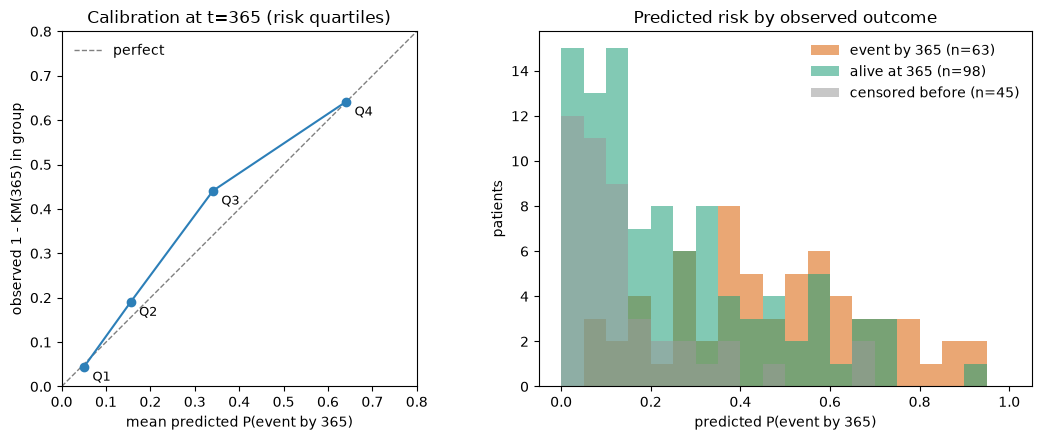

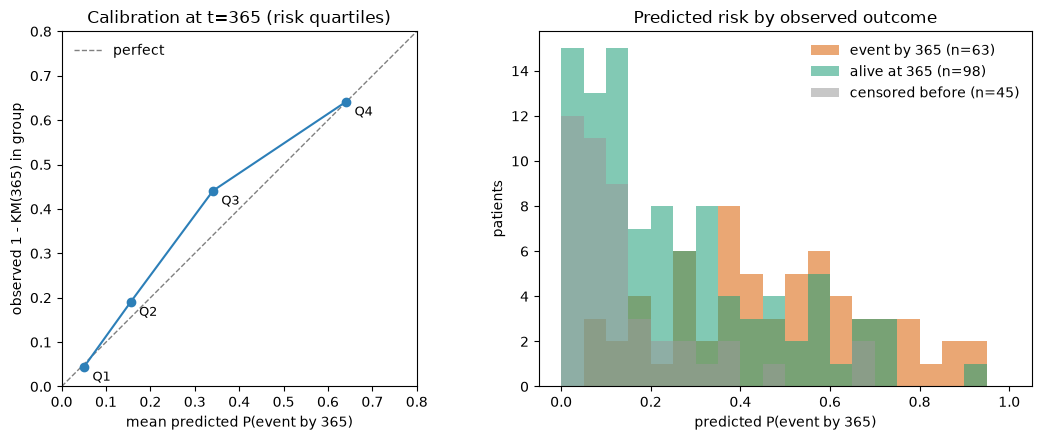

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

c = calib.reset_index()
ax1.plot([0, 0.8], [0, 0.8], "--", color="grey", lw=1, label="perfect")
ax1.plot(c["pred P(event)"], c["observed 1-KM(365)"], "-o", color="#2c7fb8")
for _, r in c.iterrows():
    ax1.annotate(r["group"], (r["pred P(event)"], r["observed 1-KM(365)"]),
                 textcoords="offset points", xytext=(6, -10), fontsize=9)
ax1.set(xlim=(0, 0.8), ylim=(0, 0.8), aspect="equal",
        xlabel="mean predicted P(event by 365)",
        ylabel="observed 1 - KM(365) in group",
        title=f"Calibration at t={T_STAR:.0f} (risk quartiles)")
ax1.legend(frameon=False)

# Distribution of the predictions by observed outcome -- overlap is what the AUC
# of 0.76 looks like. Censored patients are shown separately: they are not
# "survivors", their status at 365 is simply unknown.
bins = np.linspace(0, 1, 21)
for m, lab, col in [(died, f"event by {T_STAR:.0f}", "#d95f02"),
                    (surv, f"alive at {T_STAR:.0f}", "#1b9e77"),
                    (unk, "censored before", "#999999")]:
    ax2.hist(p_event[m], bins=bins, alpha=0.55, label=f"{lab} (n={int(m.sum())})",
             color=col)
ax2.set(xlabel="predicted P(event by 365)", ylabel="patients",
        title="Predicted risk by observed outcome")
ax2.legend(frameon=False)

fig.tight_layout()

### Reading the t=365 comparison

**Discrimination holds up.** AUC at 365 is 0.767 on the resolved subset and 0.764
IPCW-weighted — close to the 0.748 Harrell's C computed over all horizons, which is
what you'd expect since the risk score is essentially an average of these
single-horizon quantities. The near-identity of the naive and weighted AUCs says
censoring is not selecting for easy cases here.

**The probability carries information beyond the base rate.** Brier at 365 is 0.183
(IPCW) against 0.223 for a KM-only model that assigns every patient the same
$\hat S(365)=1-0.223$. That 18% reduction is the part attributable to the covariates.

**Calibration is good at the extremes and under-predicts in the middle.** Q1 and Q4
are within 0.006 of observed; Q3 predicts 0.341 against an observed 0.441, a 10-point
under-prediction. This is the same direction as the notebook's integrated
$|S-\mathrm{KM}|$ of 0.059 for CF: the curves sit too high, i.e. the model is
systematically optimistic about survival, and the error concentrates in mid-risk
patients rather than being spread evenly.

Two caveats on the quartile table. The groups are small (n≈51), so a 0.10 gap is
roughly within sampling noise for a single seed — worth noting, not worth acting on.
And Q1 contains 23 of the 45 censored patients against 3 in Q4: low-risk patients are
preferentially censored early, so its observed rate rests on the fewest actual events
(2) and leans hardest on the KM extrapolation.

## Note on the number

`Harrell's C = 0.7483` reproduces, but two caveats travel with it.

**It is the optimistic member of the pair.** Harrell's C drops censoring-incomparable
pairs instead of reweighting them; Uno's C reweights by the censoring distribution
estimated on training data. Here Harrell reads 0.7483 against Uno's 0.7403. The gap
is small, so the censoring pattern is not doing violent work, but if you report one
number for a censored cohort, report Uno's.

**It is a single seed.** Across 5 seeds the CF-over-DH discrimination advantage
averaged +0.008 on Uno's C with one seed *negative* and a standard deviation about
4x DH's; on Harrell's C the advantage is only +0.0026, smaller than that seed
variability. So this value should not be used to claim CF discriminates better than
DH. The robust CF/DH difference in the full notebook is **calibration** (integrated
$|S - \mathrm{KM}|$ of 0.059 vs 0.034), not ranking — and the t=365 section above
shows what that miscalibration looks like at a single clinically meaningful horizon.

**What is still intentionally dropped**, and none of it affects Harrell's C:
`cf_row_table` (the selection diagnostic), the DH model, $S^\alpha$ calibration, the
IPCW-trained variant, and SHAP. Kaplan-Meier is now used, but only for the t=365
calibration check, not for the C-index.